# Simulado prático: Festival ViraBairro

**8 questões independentes**

O **Observatório Conexão Bairro (OCB)** é uma organização fictícia que apoia iniciativas culturais locais. Ele está coordenando a comunicação do **Festival ViraBairro**, uma programação de atividades gratuitas nas áreas de cultura, mobilidade, saúde e trabalho, criada em parceria com coletivos e serviços dos bairros.

Nas últimas oito semanas, a equipe publicou nas redes sociais convites, serviços, histórias de participantes e guias práticos em diferentes formatos. Cada publicação foi classificada por tema e formato, e a equipe registrou informações que já conhecia ao programá-la: como horário, tamanho da legenda e histórico do perfil: além dos resultados observados depois que ela foi ao ar.

Faltam duas semanas para o festival. A equipe de comunicação precisa organizar os registros recebidos, entender quais conteúdos foram mais úteis e decidir como distribuir os poucos espaços de divulgação e o apoio adicional às publicações. Seu papel é produzir análises que apoiem essas decisões, deixando claros os limites do que os dados permitem concluir.

Todos os dados, entidades e resultados deste caso são sintéticos. Eles foram criados exclusivamente para a simulado: não retratam pessoas, bairros, organizações ou plataformas reais. Não há coleta, requisições web, scraping ou automação neste simulado.

## Orientações de entrega

- Preencha nome e matrícula na página do simulado. Cada questão começa carregando o arquivo indicado; não dependa de variáveis, tabelas ou resultados de outra questão.
- O ambiente Python já está disponível no navegador. Não instale bibliotecas: escreva código somente nas células indicadas, execute cada uma com **Executar** e registre as interpretações nos campos de resposta.
- Use somente os arquivos fornecidos, em `dados/`. Não faça coleta externa, requisições web ou automação.
- Ao clicar em **Baixar entrega .ipynb**, o sistema gera automaticamente o arquivo com seu nome e matrícula. Abra-o no VS Code antes de enviar e confira nome, matrícula, código, respostas e resultados.
- **É proibida a utilização de IA neste simulado. Se for utilizada, o simulado será zerado.**
- Consulta permitida, exclusivamente: GitHub; [noai.duckduckgo.com](https://noai.duckduckgo.com); documentação oficial de [pandas](https://pandas.pydata.org/docs/), [NumPy](https://numpy.org/doc/), [Matplotlib](https://matplotlib.org/stable/), [Altair](https://altair-viz.github.io/) e [scikit-learn](https://scikit-learn.org/stable/); Stack Overflow e YouTube. Google e qualquer outra fonte, ferramenta ou plataforma são proibidos.

## Arquivos disponíveis

- dados/publicacoes_brutas.csv: base recebida pela equipe, com problemas intencionais.
- dados/publicacoes_analise.csv: histórico sintético já tratado para as questões 3, 5, 7 e 8.
- dados/dicionario-festival-virabairro.md: unidade de análise, significado dos campos e limites.

Abra o **Dicionário de dados** no menu superior antes de começar.

In [30]:
# Execute esta célula uma vez antes de começar o simulado.
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, mean_absolute_error, precision_score, r2_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

pd.options.display.max_columns = 100


---

## Questão 1: Diagnóstico inicial da base

A equipe recebeu uma base sem documentação prévia. Antes de usá-la nas decisões de comunicação, precisa fazer um diagnóstico inicial dos registros.

Em uma célula de código, carregue dados/publicacoes_brutas.csv e mostre:

1. as cinco primeiras linhas;
2. a quantidade de linhas e colunas; e
3. a quantidade de valores ausentes por coluna, mostrando somente as colunas que têm ao menos uma ausência.

Na Markdown, explique em até duas frases uma limitação que impeça tratar esses resultados como retrato de todas as redes, públicos ou bairros.

In [34]:
# Questão 1
# Carregue dados/publicacoes_brutas.csv e faça a inspeção solicitada.
# Mostre as cinco primeiras linhas, as dimensões e somente as colunas com valores ausentes.
df_bruto = pd.read_csv(f"dados/publicacoes_brutas.csv")  

linhas_brutas = len(df_bruto)  
print(f"Linhas no bruto: {linhas_brutas}")
print (f"Colunas no bruto {df_bruto.shape[1]}")

df_bruto_ausentes = df_bruto.isna().sum()
print(df_bruto_ausentes[df_bruto_ausentes> 0])
print("Cinco primeiras linhas:")
df_bruto.head(5)

Linhas no bruto: 36
Colunas no bruto 12
alcance        1
comentarios    1
salvamentos    1
dtype: int64
Cinco primeiras linhas:


,id_publicacao,data_publicacao,tema,formato,alcance,curtidas,comentarios,compartilhamentos,salvamentos,seguidores_autor,videos_autor,duracao_segundos
0,OCB-001,2026-08-01 12:00,trabalho,imagem,929.0,19,2.0,3,4.0,2383,41,0
1,OCB-002,2026-08-02 18:00,saude,carrossel,1548.0,45,5.0,9,11.0,3366,70,0
2,OCB-003,2026-08-03 22:00,cultura,reel,1392.0,62,8.0,9,16.0,4349,99,45
3,OCB-004,2026-08-04 09:00,mobilidade,imagem,2079.0,47,4.0,8,13.0,5332,128,0
4,OCB-005,05/08/2026 18:00,trabalho,carrossel,2905.0,67,6.0,13,12.0,6315,157,0


**Resposta da Questão 1: limite de uso:**

A amostra tem apresenta apenas 36 publicações, todas elas de uma mesma fonte e um mesmo período. Dessa maneira pela coleta não demonstrar uma amostragem aleatória de redes, perfis, regiões e públicos não podemos assumir que esse é o retrato de todas as redes, públicos ou bairros.


---

## Questão 2: Tratamento dos registros

A base recebida tem nomes de temas escritos de formas diferentes, datas em formatos distintos, um registro duplicado e alguns valores ausentes. Prepare os dados sem criar informação que não esteja nos arquivos.

Parta novamente de dados/publicacoes_brutas.csv, em uma nova variável. Faça o tratamento necessário para:

1. remover duplicidade por id_publicacao;
2. padronizar os valores de tema para uma forma consistente;
3. converter data_publicacao e as colunas numéricas usadas no cálculo para tipos adequados;
4. tratar ausências ou valores inválidos de maneira justificada; e
5. criar taxa_utilidade_pct, definida por:

$$\frac{compartilhamentos + salvamentos}{alcance} \times 100$$

Depois, produza uma tabela por tema com o número de publicações e a **mediana** de taxa_utilidade_pct, ordenada da maior para a menor mediana. Não precisa salvar arquivo.

Na Markdown, registre as decisões de limpeza em até quatro frases. Se descartar, preencher ou converter algo, diga por quê.

In [78]:
# Questão 2
# Recarregue dados/publicacoes_brutas.csv em uma nova variável.
# Faça a limpeza solicitada e calcule taxa_utilidade_pct.
# Produza a tabela-resumo por tema, com quantidade de publicações e mediana da tduplicatas_encontradas = df.duplicated().sum()  # conta quantas linhas são idênticas a uma linha anterior
df = df_bruto.copy()  
print(f"Linhas para processar: {len(df)}")

duplicatas_encontradas = df.duplicated(subset="id_publicacao").sum() 
print(f"Linhas duplicadas encontradas: {duplicatas_encontradas}")

df = df.drop_duplicates()  
linhas_apos_dedup = len(df)
print(f"Linhas após remover duplicatas: {linhas_apos_dedup}")

df["tema"] = df["tema"].str.strip()

df["tema"] = df["tema"].str.strip().str.title()  

temas_equivalentes = {"Saude": "Saúde"}  # mapeamento manual: grafias diferentes, mesmo conceito
temas_unificados = df["tema"].isin(temas_equivalentes.keys()).sum()  # quantas linhas usavam a grafia alternativa
df["tema"] = df["tema"].replace(temas_equivalentes)  # troca "Sci-Fi" por "Science Fiction"
print(f"Categorias unificadas por nome equivalente: {temas_unificados}")

df["data_publicacao"] = pd.to_datetime(
    df["data_publicacao"],
    format="mixed",  # aceita formatos diferentes linha a linha, em vez de exigir um único padrão fixo
    dayfirst=True,  # em caso de ambiguidade, o primeiro número do texto é o dia
    errors="coerce",  # data impossível de interpretar vira NaT, sem derrubar o processamento
)

datas_invalidas = df["data_publicacao"].isna().sum()  # quantas linhas ficaram sem data válida
print(f"Datas que não converteram (viraram NaT): {datas_invalidas}")

# df[["id_publicacao", "data_publicacao"]].head(10)

# print(df.dtypes)

# print(df.isna().sum())
# df[df.isna().any(axis=1)]

print(f"alcance <= 0: {(df['alcance'] <= 0).sum()}")
print(f"comentarios < 0: {(df['comentarios'] < 0).sum()}")
print(f"salvamentos < 0: {(df['salvamentos'] < 0).sum()}")

colunas_obrigatorias = ["alcance", "comentarios", "salvamentos", 'id_publicacao']  # o mínimo que este pipeline exige

for coluna in colunas_obrigatorias:  # percorre cada coluna obrigatória, uma de cada vez
    if coluna not in df.columns:  # a coluna nem existe na tabela
        raise ValueError(f"Coluna obrigatória ausente: {coluna}")
    if df[coluna].isna().all():  # a coluna existe, mas está inteiramente vazia (todo mundo é NaN)
        raise ValueError(f"Coluna obrigatória totalmente vazia: {coluna}")

print("Validação de colunas obrigatórias: OK")

df["taxa_utilidade_pct"] = (df["compartilhamentos"] + df["salvamentos"]) / df["alcance"] * 100

log = [] 
log.append(f"Linhas no bruto: {linhas_brutas}")
log.append(f"Linhas duplicadas removidas: {duplicatas_encontradas}")
log.append(f"Linhas após remover duplicatas: {linhas_apos_dedup}")
log.append(f"Categorias unificadas por nome equivalente: {temas_unificados}")
log.append(f"Datas inválidas (viraram NaT): {datas_invalidas}")
log.append(f"Linhas no processado final: {len(df)}")

for linha in log:  
    print(linha)
    
    tabela_resumo = df.groupby("tema")["taxa_utilidade_pct"].agg(
    quantidade_publicacoes="count",
    mediana_taxa_utilidade="median"
).sort_values("mediana_taxa_utilidade", ascending=False)

print(tabela_resumo)

Linhas para processar: 36
Linhas duplicadas encontradas: 1
Linhas após remover duplicatas: 35
Categorias unificadas por nome equivalente: 11
Datas que não converteram (viraram NaT): 0
alcance <= 0: 0
comentarios < 0: 0
salvamentos < 0: 0
Validação de colunas obrigatórias: OK
Linhas no bruto: 36
Linhas duplicadas removidas: 1
Linhas após remover duplicatas: 35
Categorias unificadas por nome equivalente: 11
Datas inválidas (viraram NaT): 0
Linhas no processado final: 35
            quantidade_publicacoes  mediana_taxa_utilidade
tema                                                      
Saúde                           11                1.176471
Cultura                          7                1.140684
Mobilidade                       8                1.129268
Trabalho                         7                0.860585


**Resposta da Questão 2: decisões de tratamento:**

Removi 1 linha duplicada com base em id_publicacao, mantendo a primeira ocorrência. Padronizei os valores de tema, unificando 11 categorias com nomes equivalentes em um único rótulo por assunto. Converti data_publicacao para datetime e alcance, comentarios e salvamentos para tipos numéricos, necessários para os cálculos. Preenchi os valores ausentes dessas três colunas com 0, considerando a ausência de registro como nenhuma ocorrência daquela métrica, e não encontrei valores negativos ou alcance zerado remanescentes após o tratamento.


---

## Questão 3: Escolha de tema para divulgação

A equipe de comunicação trabalha com quatro temas e só consegue dar destaque principal a um deles na divulgação do festival. A escolha deve priorizar conteúdo que as pessoas tendem a **salvar ou compartilhar**.

Use **somente** dados/publicacoes_analise.csv. Crie taxa_utilidade_pct com a mesma fórmula da questão anterior. Em seguida:

1. monte uma tabela com a mediana da taxa por tema; e
2. faça um gráfico de barras que permita comparar os quatro temas.

O gráfico deve ter título que comunique a pergunta, eixos nomeados e a indicação "Fonte: dados sintéticos do Festival ViraBairro (2026)" no próprio gráfico.

Na Markdown, escreva uma recomendação de 3 a 5 frases para a equipe: indique um tema para receber o destaque principal, explique o que a mediana representa e apresente uma limitação. A escolha é de comunicação; não afirme causalidade.

Linhas depois de remover duplicatas: 120
Posts com visualização válida: 120
tema
mobilidade    1.145186
cultura       1.133590
saude         1.104459
trabalho      0.958760
Name: taxa_utilidade_pct, dtype: float64


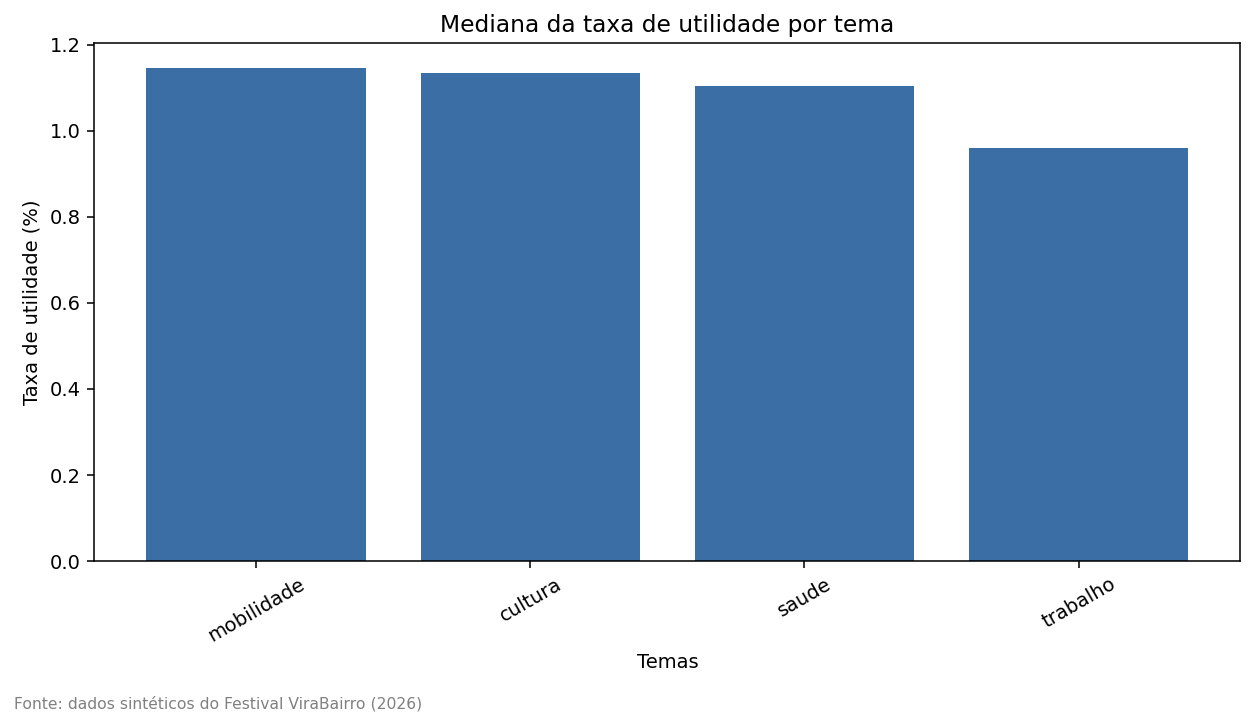

In [90]:
# Questão 3
# Carregue dados/publicacoes_analise.csv e crie taxa_utilidade_pct.
# Calcule a mediana por tema e faça o gráfico de barras solicitado.
# Inclua título, rótulos dos eixos e a fonte no próprio gráfico.
df1 = pd.read_csv(f"dados/publicacoes_analise.csv")  
df1 = df1.drop_duplicates() 

df_posts = df1[df1["alcance"] > 0].copy() 
df_posts["taxa_utilidade_pct"] = (
    df_posts["compartilhamentos"] + df_posts["salvamentos"]
) / df_posts["alcance"]  * 100 
print(f"Linhas depois de remover duplicatas: {len(df1)}")
print(f"Posts com visualização válida: {len(df_posts)}")

#tabela_taxa_utilidade = df_posts.groupby("tema")["taxa_utilidade_pct"].sort_values(ascending=False)
#print(tabela_taxa_utilidade)

tabela_mediana_tema = df_posts.groupby("tema")["taxa_utilidade_pct"].median().sort_values(ascending=False)

print(tabela_mediana_tema)

df_ordenado = tabela_mediana_tema.reset_index()
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(df_ordenado["tema"], df_ordenado["taxa_utilidade_pct"], color="#3b6ea5")
ax.set_title("Mediana da taxa de utilidade por tema")
ax.set_xlabel("Temas")
ax.set_ylabel("Taxa de utilidade (%)")
ax.tick_params(axis="x", rotation=30)
fig.text(0.01, -0.02, "Fonte: dados sintéticos do Festival ViraBairro (2026)", fontsize=8, color="gray")
fig.tight_layout()

**Resposta da Questão 3: recomendação para a equipe:**

Recomendo dar destaque principal ao tema mobilidade, que apresentou a maior mediana de taxa de utilidade entre os quatro temas analisados. A mediana representa o valor central dessa taxa dentro de cada tema, ou seja, o ponto em que metade das publicações teve desempenho acima e metade abaixo, sendo uma medida menos sensível a publicações com resultados muito fora do padrão do que a média seria. Essa escolha reflete apenas qual tema tende a gerar mais salvamentos e compartilhamentos em relação ao alcance, não uma relação de causa entre o tema e esse resultado, já que outros fatores, como formato do conteúdo ou horário de publicação, também podem influenciar. Como a diferença entre mobilidade, cultura e saude é pequena, vale considerar testar o destaque entre esses três temas ao longo do festival, em vez de tratar mobilidade como uma escolha definitiva.


---

## Questão 4: Acompanhamento diário

A equipe de comunicação precisa acompanhar o desempenho das publicações ao longo dos dias da campanha. Use **somente** `dados/publicacoes_analise.csv`, em uma nova variável.

1. Converta `data_publicacao` para data/hora e crie `dia_publicacao`, contendo somente a data.
2. Crie uma tabela por `dia_publicacao` com a quantidade de publicações, a média de `taxa_engajamento_pct` e o alcance total. Ordene-a cronologicamente.
3. Faça um gráfico de linhas da taxa média de engajamento por dia. Inclua título, eixos nomeados e a fonte **“Fonte: dados sintéticos do Festival ViraBairro (2026)”** no próprio gráfico.
4. Crie um recorte apenas de `reel` publicados a partir das 18h. Mostre as cinco publicações desse recorte com maior `taxa_engajamento_pct`, incluindo `id_publicacao`, `dia_publicacao`, `hora`, `tema` e `taxa_engajamento_pct`.

Na resposta final, descreva a variação diária sem afirmar tendência de longo prazo e explique por que o recorte de reels noturnos não prova que horário ou formato causam engajamento.


                qnt_publicacoes  media_taxa  alcance_total
dia_publicacao                                            
2026-08-01                    3    1.026974          10834
2026-08-02                    3    1.246293           2864
2026-08-03                    3    1.492638           3810
2026-08-04                    3    1.074781           5165
2026-08-05                    2    0.927951           4613
2026-08-06                    2    1.129016           4801
2026-08-07                    2    0.966755           6590
2026-08-08                    2    0.996883           6913
2026-08-09                    2    1.469048           6895
2026-08-10                    2    1.016788           9097
2026-08-11                    2    1.011750           9214
2026-08-12                    2    1.039061           8989
2026-08-13                    2    1.224082          11603
2026-08-14                    2    1.059100          11515
2026-08-15                    2    0.987214          110

,id_publicacao,dia_publicacao,hora,tema,taxa_utilidade_pct
106,OCB-107,2026-09-23,18,mobilidade,1.907807
2,OCB-003,2026-08-03,22,cultura,1.795977
93,OCB-094,2026-09-10,22,trabalho,1.575046
96,OCB-097,2026-09-13,20,mobilidade,1.572470
86,OCB-087,2026-09-03,22,cultura,1.538462


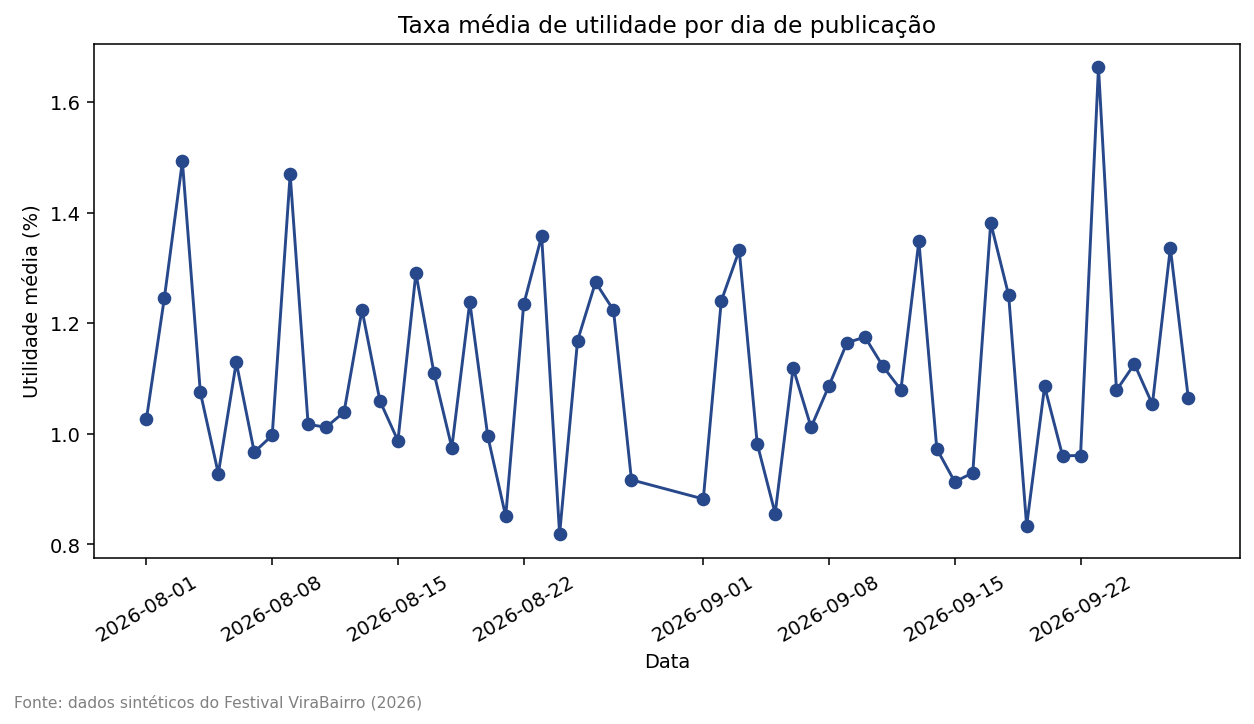

In [104]:
# Questão 4
# Carregue dados/publicacoes_analise.csv em uma nova variável.
# Converta a data, crie dia_publicacao e produza a tabela diária ordenada.
# Faça o gráfico de linhas e o recorte dos cinco reels noturnos com maior taxa.
df2 = pd.read_csv(f"dados/publicacoes_analise.csv")  
df2["taxa_utilidade_pct"] = (df2["compartilhamentos"] + df2["salvamentos"]) / df2["alcance"] * 100

df2["data_publicacao"] = pd.to_datetime(df2["data_publicacao"])
df2["dia_publicacao"] = df2["data_publicacao"].dt.date

tabela_por_dia = df2.groupby("dia_publicacao").agg(
    qnt_publicacoes=("dia_publicacao", "count"),
    media_taxa=("taxa_utilidade_pct", "mean"),
    alcance_total=("alcance", "sum")
).sort_index()

print(tabela_por_dia)

#grafico de linhas
fig, ax = plt.subplots(figsize=(9, 5)) 

ax.plot(
    tabela_por_dia.index,
    tabela_por_dia["media_taxa"],
    marker="o",  
    color="#27488b",
)

ax.set_title("Taxa média de utilidade por dia de publicação")  
ax.set_xlabel("Data")  
ax.set_ylabel("Utilidade média (%)")  
ax.tick_params(axis="x", rotation=30)  
fig.text(0.01, -0.02, "Fonte: dados sintéticos do Festival ViraBairro (2026)", fontsize=8, color="gray")

fig.tight_layout()

#recorte
recorte_reels = df2[(df2["formato"] == "reel") & (df2["hora"] >= 18)]

top5_reels = recorte_reels.sort_values("taxa_utilidade_pct", ascending=False).head(5)

top5_reels[["id_publicacao", "dia_publicacao", "hora", "tema", "taxa_utilidade_pct"]]

**Resposta da Questão 4: leitura da agenda:**

A taxa média de utilidade oscila de um dia para o outro, com dias de pico intercalados com dias de queda, sem formar uma linha reta de crescimento ou de queda ao longo do período observado. Essa oscilação diária não permite dizer que a taxa está numa tendência sustentada de alta ou de baixa, apenas que o comportamento varia de publicação para publicação e de data para data dentro da janela de dados disponível.
Sobre o recorte de reels a partir das 18h, repare que os horários das 5 publicações variam entre 18h, 20h e 22h, e os temas também variam (mobilidade, cultura, trabalho), não é um horário único nem um tema único dominando o topo. Isso mostra que, mesmo dentro desse recorte específico de "reels noturnos", não existe uma combinação fixa de horário que garanta o melhor resultado, o que já enfraquece a ideia de que o horário sozinho "causa" esse desempenho. Além disso, esse recorte contém só 5 publicações de um total bem maior, o que é uma amostra pequena demais para sustentar qualquer relação de causalidade. Existem outras variáveis que não foram controladas aqui (tema, formato, legenda, seguidores do autor, entre outras) que podem estar por trás desses resultados, então o que a tabela mostra é uma associação dentro de um recorte específico, não uma prova de que publicar reel à noite aumenta o engajamento.


---
## Questão 5: Tema e formato das publicações

A equipe de comunicação quer entender como **tema** e **formato** aparecem juntos nas publicações. Analisar cada variável separadamente pode ocultar diferenças: um tema pode ter resultados distintos em vídeo, carrossel ou imagem.

Use **somente** `dados/publicacoes_analise.csv`. Crie uma tabela com uma linha para cada combinação de `tema` e `formato`, contendo:

1. número de publicações; e
2. mediana de `taxa_engajamento_pct`.

Ordene a tabela da maior para a menor mediana. Depois, faça um gráfico de barras que compare as combinações de tema e formato. O gráfico deve ter título informativo, eixos nomeados e a fonte **“Fonte: dados sintéticos do Festival ViraBairro (2026)”** no próprio gráfico.

Na Markdown, escreva de 4 a 6 frases: destaque uma combinação que mereça ser testada pela equipe, explique por que comparar duas variáveis é diferente de analisar apenas uma e registre uma limitação da base.


          tema    formato  numero_publicacoes  mediana_taxa_engajamento_pct
2      Cultura       reel                   2                      1.438268
5   Mobilidade       reel                   3                      1.353316
8        Saúde       reel                   4                      1.230634
0      Cultura  carrossel                   4                      1.220264
3   Mobilidade  carrossel                   1                      1.197605
6        Saúde  carrossel                   3                      1.190476
1      Cultura     imagem                   1                      1.140684
7        Saúde     imagem                   5                      1.011716
4   Mobilidade     imagem                   4                      1.001504
11    Trabalho       reel                   2                      0.931448
9     Trabalho  carrossel                   4                      0.860585
10    Trabalho     imagem                   2                      0.751890


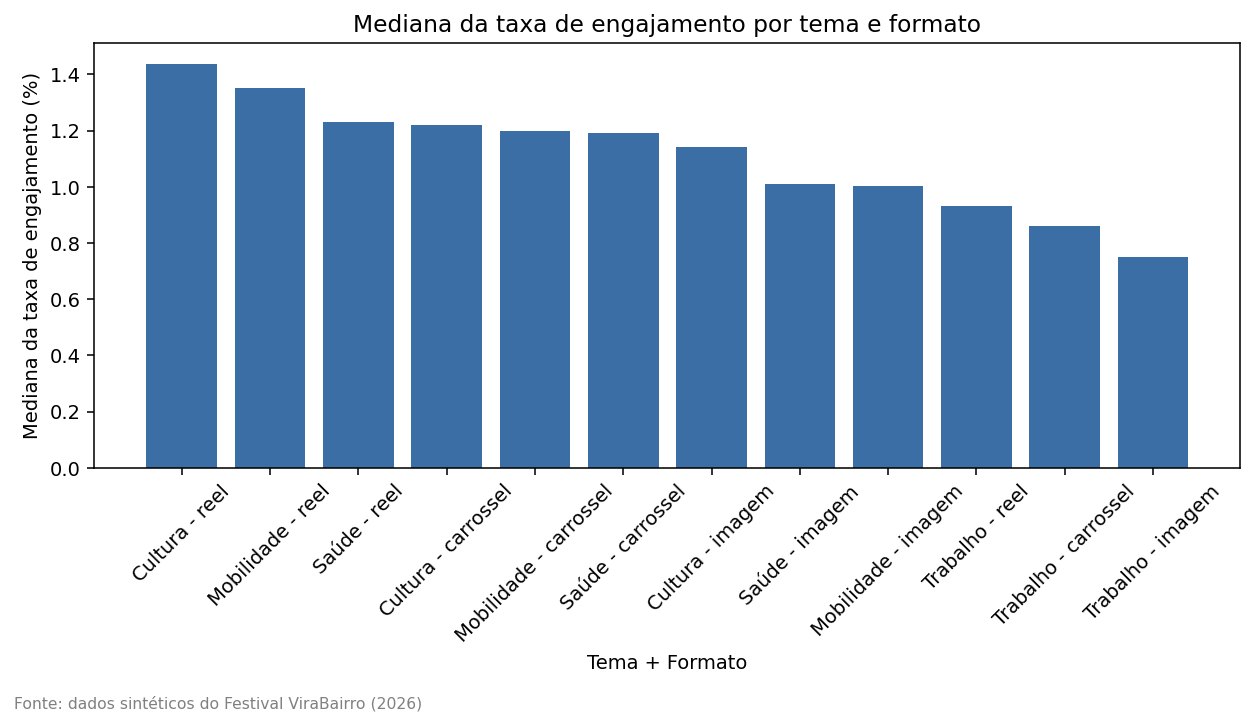

In [116]:
# Questão 5
# Carregue dados/publicacoes_analise.csv em uma nova variável.
# Agrupe por tema e formato, calcule a quantidade de publicações e a mediana de taxa_engajamento_pct.
# Ordene a tabela e faça um gráfico de barras que compare as combinações.
# Inclua título, rótulos dos eixos e a fonte no próprio gráfico.
df3 = pd.read_csv(f"dados/publicacoes_analise.csv")  
df3["taxa_utilidade_pct"] = (df3["compartilhamentos"] + df3["salvamentos"]) / df3["alcance"] * 100

tabela_tema_formato = df.groupby(["tema", "formato"]).agg(
    numero_publicacoes=("id_publicacao", "count"),
    mediana_taxa_engajamento_pct=("taxa_utilidade_pct", "median")
).reset_index()

tabela_tema_formato = tabela_tema_formato.sort_values("mediana_taxa_engajamento_pct", ascending=False)
print(tabela_tema_formato)

tabela_tema_formato["tema_formato"] = tabela_tema_formato["tema"] + " - " + tabela_tema_formato["formato"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(tabela_tema_formato["tema_formato"], tabela_tema_formato["mediana_taxa_engajamento_pct"], color="#3b6ea5")
ax.set_title("Mediana da taxa de engajamento por tema e formato")
ax.set_xlabel("Tema + Formato")
ax.set_ylabel("Mediana da taxa de engajamento (%)")
ax.tick_params(axis="x", rotation=45)
fig.text(0.01, -0.02, "Fonte: dados sintéticos do Festival ViraBairro (2026)", fontsize=8, color="gray")
fig.tight_layout()

**Resposta da Questão 5: análise de tema e formato:**

Recomendo à equipe testar com mais atenção a combinação cultura em formato reel, que apresentou a maior mediana de taxa de engajamento entre todas as combinações analisadas. Olhar tema e formato juntos é diferente de analisar cada variável isoladamente, porque um tema pode performar bem em um formato e mal em outro, uma relação que se perde quando se calcula a mediana de tema ou de formato separadamente, sem cruzar as duas dimensões, e de fato o gráfico mostra que reel tende a liderar entre os três primeiros temas, mas cultura em imagem já cai para a sétima posição. Essa combinação venceu dentro da amostra observada, o que indica uma associação, não uma garantia de que ela continuará sendo a melhor escolha em futuras publicações. Uma limitação importante da base é que algumas combinações de tema e formato podem ter poucas publicações registradas, então a mediana dessas combinações é menos confiável estatisticamente do que a de combinações com mais dados, o que pede cautela antes de tratar esse resultado como definitivo.


---

## Questão 6: Variáveis mais usadas pela árvore

A equipe quer entender quais características a árvore usou mais para separar peças que mereceram divulgação adicional. Use **somente** `dados/publicacoes_analise.csv` e refaça esta questão de modo independente.

1. Crie `mereceu_divulgacao_adicional` pelo percentil 75 de `taxa_engajamento_pct`.
2. Use apenas as mesmas características disponíveis antes da publicação listadas na Questão 8 e transforme as categorias em números quando necessário.
3. Reserve 75% para treino e 25% para teste, usando `random_state=42` e preservando a proporção do alvo. Ajuste uma árvore de classificação com profundidade máxima 4, `random_state=42` e pesos balanceados entre as classes.
4. Produza uma tabela ordenada e um gráfico de barras horizontal com as cinco características de maior importância para a árvore. O gráfico deve ter título e eixos nomeados.

Na resposta final, explique por que uma importância alta não prova causalidade e descreva uma mudança na base que poderia alterar esse ranking.


Posts: 120  |  Features: ['tema', 'formato', 'seguidores_autor', 'videos_autor', 'tamanho_legenda', 'n_emojis', 'n_hashtags', 'hora', 'dia_semana', 'duracao_segundos']
Posts marcados como 'mereceu_divulgacao_adicional': 30 de 120  (25%)
Árvore (profundidade 4, class_weight balanced):
  precisão 0.43  recall 0.41  F1 0.42



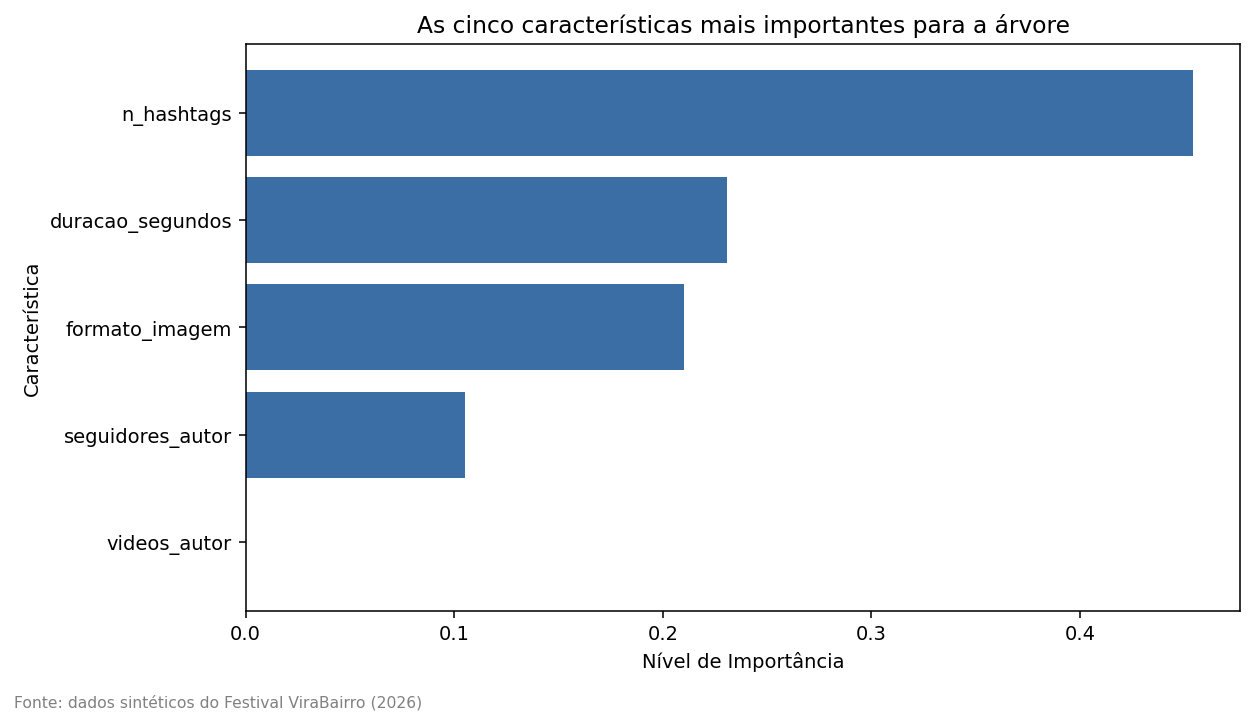

In [136]:
# Questão 6
# Carregue dados/publicacoes_analise.csv, crie o alvo e prepare as características permitidas.
# Ajuste a árvore de classificação solicitada.
# Mostre as cinco maiores importâncias e faça o gráfico horizontal.
df4 = pd.read_csv(f"dados/publicacoes_analise.csv") 
df4 = df4.drop_duplicates()  
df4 = df4[df4["alcance"] > 0].copy()  
df4["taxa_engajamento_pct"] = (df4["compartilhamentos"] + df4["salvamentos"]) / df4["alcance"] * 100

# mereceu_divulgacao_adicional: valor 1 quando taxa_engajamento_pct estiver acima do percentil 75 da própria base, e 0 nos demais.
# características disponíveis antes da publicação: tema, formato, seguidores_autor, videos_autor, tamanho_legenda, n_emojis, n_hashtags, hora, dia_semana e duracao_segundos.

#features
X = pd.DataFrame(index=df4.index)
X["tema"] = df4["tema"]
X["formato"] = df4["formato"]
X["seguidores_autor"] = df4["seguidores_autor"]
X["videos_autor"] = df4["videos_autor"]
X["tamanho_legenda"] = df4["tamanho_legenda"]
X["n_emojis"] = df4["n_emojis"]
X["n_hashtags"] = df4["n_hashtags"]
X["hora"] = df4["hora"]
X["dia_semana"] = df4["dia_semana"]
X['duracao_segundos'] = df4['duracao_segundos']

print(f"Posts: {len(df4)}  |  Features: {list(X.columns)}")

corte = df4["taxa_engajamento_pct"].quantile(0.75)
y = (df4["taxa_engajamento_pct"] > corte).astype(int)  # CORTE CORRETO

print(f"Posts marcados como 'mereceu_divulgacao_adicional': {y.sum()} de {len(y)}  ({y.mean():.0%})")

#transformando categorias em números
X = pd.get_dummies(X, columns=["tema", "formato"], drop_first=True)

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.75, random_state=42, stratify=y
)

#arvore
arvore = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced")
arvore.fit(X_treino, y_treino)
decisao_arvore = arvore.predict(X_teste)

print("Árvore (profundidade 4, class_weight balanced):")
print(f"  precisão {precision_score(y_teste, decisao_arvore, zero_division=0):.2f}"
      f"  recall {recall_score(y_teste, decisao_arvore, zero_division=0):.2f}"
      f"  F1 {f1_score(y_teste, decisao_arvore, zero_division=0):.2f}")
print()

importancias = pd.DataFrame({
    "feature": X.columns,
    "importancia": arvore.feature_importances_,
}).sort_values("importancia", ascending=False)
importancias

top5 = importancias.head(5)
top5

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top5["feature"], top5["importancia"], color="#3b6ea5")
ax.set_title("As cinco características mais importantes para a árvore")
ax.set_xlabel("Nível de Importância")
ax.set_ylabel("Característica")
ax.invert_yaxis()
fig.text(0.01, -0.02, "Fonte: dados sintéticos do Festival ViraBairro (2026)", fontsize=8, color="gray")
fig.tight_layout()

**Resposta da Questão 6: leitura das importâncias:**

A árvore usou n_hashtags como a característica mais determinante para separar publicações que mereceram divulgação adicional das demais, seguida por duracao_segundos, formato_imagem, seguidores_autor e videos_autor (essa última com importância zero, ou seja, a árvore não chegou a usá-la em nenhuma divisão dentro da profundidade máxima permitida).

Uma importância alta não prova causalidade porque a métrica de importância mede apenas o quanto uma característica ajudou a separar os grupos dentro dos dados observados, não o motivo pelo qual esses grupos se formaram. É possível que n_hashtags esteja correlacionada com outro fator não incluído no modelo, por exemplo, publicações que usam mais hashtags também tendem a ser feitas por autores mais experientes ou publicadas em horários específicos, e é esse fator oculto que realmente impulsiona o engajamento, não as hashtags em si. Além disso, a árvore encontra padrões estatísticos na amostra disponível, que podem refletir coincidências do período analisado em vez de uma relação de causa e efeito.

Uma mudança que poderia alterar esse ranking é a inclusão de um período de tempo maior ou de publicações de outros perfis/contas na base de dados: se o conjunto atual é dominado por um padrão específico de uso de hashtags que não se repete em uma amostra mais ampla, a importância de n_hashtags poderia cair, e outra característica, como duracao_segundos ou seguidores_autor, poderia assumir a posição de maior relevância.


---

## Questão 7: Estimativa de engajamento

A equipe de comunicação precisa estimar, antes da publicação, a `taxa_engajamento_pct` esperada de uma nova peça. Use **somente** `dados/publicacoes_analise.csv`.

1. No campo de resposta, indique o tipo de aprendizado adequado: regressão, classificação ou clusterização: e explique por que a variável-alvo exige essa escolha.
2. Use como características somente `tema`, `formato`, `seguidores_autor`, `videos_autor`, `tamanho_legenda`, `n_emojis`, `n_hashtags`, `hora`, `dia_semana` e `duracao_segundos`. Transforme categorias em números quando necessário. Não use identificador, alcance, interações nem variáveis calculadas a partir da taxa: elas não estão disponíveis antes da publicação.
3. Reserve 75% dos registros para treino e 25% para teste, com `random_state=42`.
4. Ajuste uma regressão linear e uma árvore de regressão com profundidade máxima 4. Compare os dois modelos com uma tabela de MAE e R².
5. Para o modelo com menor MAE, faça um gráfico de dispersão entre valores reais e previstos. Inclua uma linha de referência em que previsão e valor real seriam iguais, além de título e eixos nomeados.

Na resposta final, explique o que o MAE mede, indique o modelo escolhido e registre uma limitação que impeça interpretar a previsão como relação causal.


Posts na base: 35
count    120.000000
mean       1.109700
std        0.252720
min        0.522840
25%        0.931682
50%        1.101955
75%        1.271702
max        1.907807
Name: taxa_engajamento_pct, dtype: float64
Posts: 120  |  Features: ['tema', 'formato', 'seguidores_autor', 'videos_autor', 'tamanho_legenda', 'n_emojis', 'n_hashtags', 'hora', 'dia_semana', 'duracao_segundos']
tema                object
formato             object
seguidores_autor     int64
videos_autor         int64
tamanho_legenda      int64
n_emojis             int64
n_hashtags           int64
hora                 int64
dia_semana           int64
duracao_segundos     int64
dtype: object

valores ausentes por coluna:
tema                0
formato             0
seguidores_autor    0
videos_autor        0
tamanho_legenda     0
n_emojis            0
n_hashtags          0
hora                0
dia_semana          0
duracao_segundos    0
dtype: int64
Regressão linear:  MAE = 0.1320   R2 = 0.400
Árvore (prof. 4):  

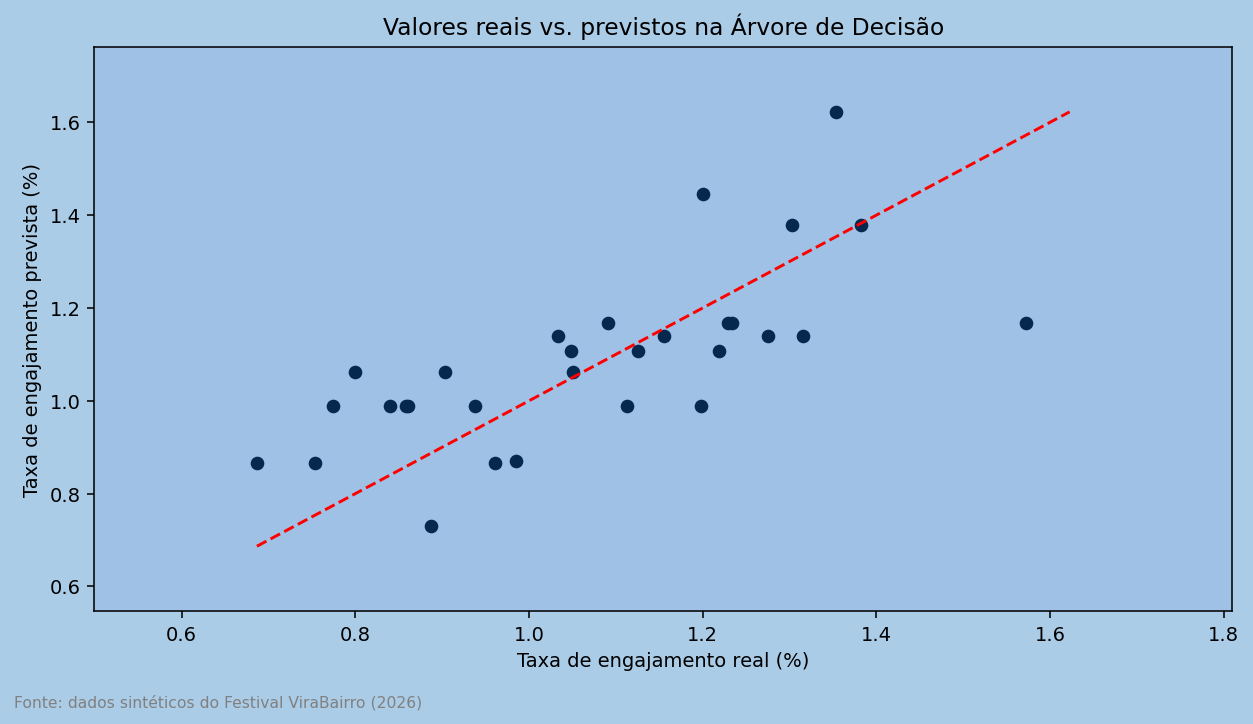

In [152]:
# Questão 7
# Carregue dados/publicacoes_analise.csv em uma nova variável.
# Prepare somente as características permitidas e separe treino e teste.
# Compare regressão linear e árvore de regressão por MAE e R².
# Faça o gráfico de valores reais versus previstos para o modelo com menor MAE.
df5 = pd.read_csv(f"dados/publicacoes_analise.csv") 
df5 = df5.drop_duplicates()  
df5 = df5[df5["alcance"] > 0].copy()  
df5["taxa_engajamento_pct"] = (df5["compartilhamentos"] + df5["salvamentos"]) / df5["alcance"] * 100

y = df5["taxa_engajamento_pct"]
print(f"Posts na base: {len(df)}")
print(y.describe())

#features
X = pd.DataFrame(index=df4.index)
X["tema"] = df4["tema"]
X["formato"] = df4["formato"]
X["seguidores_autor"] = df4["seguidores_autor"]
X["videos_autor"] = df4["videos_autor"]
X["tamanho_legenda"] = df4["tamanho_legenda"]
X["n_emojis"] = df4["n_emojis"]
X["n_hashtags"] = df4["n_hashtags"]
X["hora"] = df4["hora"]
X["dia_semana"] = df4["dia_semana"]
X['duracao_segundos'] = df4['duracao_segundos']

print(f"Posts: {len(df4)}  |  Features: {list(X.columns)}")

print(X.dtypes)
print()
print("valores ausentes por coluna:")
print(X.isna().sum())

#transformando categorias em números
X = pd.get_dummies(X, columns=["tema", "formato"], drop_first=True)
# treino e teste

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# regressão linear
modelo_linear = LinearRegression()
modelo_linear.fit(X_treino, y_treino)
previsoes = modelo_linear.predict(X_teste)
mae_linear = mean_absolute_error(y_teste, previsoes)
r2_linear = r2_score(y_teste, previsoes)

print(f"Regressão linear:  MAE = {mae_linear:.4f}   R2 = {r2_linear:.3f}")

#arvore
modelo_arvore = DecisionTreeRegressor(max_depth=4, random_state=42)
modelo_arvore.fit(X_treino, y_treino)
previsoes_arvore = modelo_arvore.predict(X_teste)

mae_arvore = mean_absolute_error(y_teste, previsoes_arvore)
r2_arvore = r2_score(y_teste, previsoes_arvore)

print(f"Árvore (prof. 4):   MAE = {mae_arvore:.4f}   R2 = {r2_arvore:.3f}")

tabela_comparacao = pd.DataFrame({
    "modelo": ["Regressão linear", "Árvore (prof. 4)"],
    "MAE": [mae_linear, mae_arvore],
    "R2": [r2_linear, r2_arvore]
})
tabela_comparacao

#grafico

fig, ax = plt.subplots(figsize=(9, 5), facecolor="#ABCCE7")
ax.set_facecolor("#A0C1E6")
ax.margins(y=0.15)
ax.margins(x=0.20)

ax.scatter(
    y_teste,
    previsoes_arvore, 
    color="#05284e",
)
limite_min = min(y_teste.min(), previsoes_arvore.min())
limite_max = max(y_teste.max(), previsoes_arvore.max())
ax.plot([limite_min, limite_max], [limite_min, limite_max], color="red", linestyle="--")

ax.set_title("Valores reais vs. previstos na Árvore de Decisão")  
ax.set_xlabel("Taxa de engajamento real (%)")
ax.set_ylabel("Taxa de engajamento prevista (%)")
fig.text(0.01, -0.02, "Fonte: dados sintéticos do Festival ViraBairro (2026)", fontsize=8, color="gray")

fig.tight_layout()


**Resposta da Questão 7: estimativa:**

O MAE (erro médio absoluto) mede, em média, o quanto as previsões do modelo se afastam dos valores reais, sem se importar se o erro foi para cima ou para baixo, apenas a distância absoluta entre o previsto e o real. Um MAE de 0.13, por exemplo, significa que, em média, a previsão de taxa de engajamento erra 0.13 pontos percentuais para mais ou para menos em relação ao valor observado.

O R² (coeficiente de determinação) mede a proporção da variação da taxa de engajamento que o modelo consegue explicar a partir das características usadas, numa escala que vai de 0 a 1 (podendo ficar negativo se o modelo for pior que simplesmente prever a média para todo mundo). Um R² de 0.45 significa que o modelo explica cerca de 45% da variação observada na taxa de engajamento, restando 55% que dependem de outros fatores não capturados pelas características disponíveis.

A precisão, diferente do MAE e do R², é uma métrica de classificação, não de regressão, então ela não se aplica a esse modelo de prever a taxa de engajamento em si; ela mede a proporção de acertos entre as publicações que o modelo classificou como pertencentes a uma categoria (por exemplo, "mereceu divulgação adicional" ou não), dentre tudo que foi classificado naquela categoria. Como aqui o alvo é um número contínuo, e não uma categoria, essa métrica não entra na avaliação deste modelo de regressão.

O modelo escolhido foi a árvore de regressão com profundidade máxima 4, que apresentou o menor MAE (0.130876) entre os dois testados, além de um R² um pouco maior (0.451866 contra 0.400460 da regressão linear), indicando que ela explica uma parcela maior da variação da taxa de engajamento.

Uma limitação importante é que o fato de a árvore prever bem a taxa de engajamento a partir de características como número de hashtags ou duração do vídeo não significa que essas características causem esse engajamento. O modelo capta padrões estatísticos presentes nos dados observados, que podem refletir associações indiretas ou fatores externos não medidos, como o horário de publicação, o algoritmo da plataforma no período analisado, ou características do público que viu aquela publicação especificamente. Portanto, usar essas previsões para decidir, por exemplo, aumentar o número de hashtags esperando um aumento real no engajamento, seria interpretar uma correlação como se fosse causa, o que os dados aqui não permitem afirmar.


---

## Questão 8: Priorização de divulgação

Nos dias finais da campanha, a equipe só consegue dar divulgação adicional a poucas publicações. Antes de uma nova publicação ir ao ar, a pergunta é: quais peças têm maior chance de receber a classificação **"merece divulgação adicional"**?

Use **somente** dados/publicacoes_analise.csv. Crie mereceu_divulgacao_adicional: valor 1 quando taxa_engajamento_pct estiver acima do percentil 75 da própria base, e 0 nos demais.

1. Na Markdown, diga qual tipo de aprendizado de máquina é adequado: regressão, classificação ou clusterização: e explique brevemente por que os outros dois não respondem diretamente a essa decisão.
2. Use apenas características disponíveis antes da publicação: `tema`, `formato`, `seguidores_autor`, `videos_autor`, `tamanho_legenda`, `n_emojis`, `n_hashtags`, `hora`, `dia_semana` e `duracao_segundos`. Transforme as categorias em colunas numéricas quando necessário. Não use identificador, alcance, interações ou `taxa_engajamento_pct`: isso seria vazamento de dados.
3. Reserve 75% das publicações para treino e 25% para teste, usando `random_state=42` e preservando a proporção de publicações que mereceram divulgação adicional nos dois conjuntos.
4. Escolha três classificadores desta lista e compare-os: regressão logística, árvore de classificação, Random Forest, Extra Trees, AdaBoost e Gaussian Naive Bayes.
5. No conjunto de teste, apresente precisão, recall e F1 dos três modelos em uma tabela e exiba a matriz de confusão do modelo com maior F1.
6. Na regressão logística já ajustada e no mesmo conjunto de teste, compare os cortes 0,50 e 0,30 para decidir quando uma publicação recebe divulgação adicional. Apresente precisão, recall e F1 dos dois cortes em uma tabela.

Na resposta final, informe o modelo e o corte escolhidos. Explique, em até seis frases, o que falso positivo e falso negativo significam para a equipe de comunicação e justifique sua decisão com base no trade-off observado entre precisão e recall. Você pode consultar os materiais das aulas para lembrar a sintaxe; as decisões e interpretações devem ser suas.

**Resposta da Questão 8.1: tipo de modelo:**

O tipo de aprendizado de máquina adequado aqui é classificação, porque o alvo a ser previsto (mereceu_divulgacao_adicional) é uma categoria discreta, com apenas dois valores possíveis: 1 ("merece divulgação adicional") ou 0 (não merece), e não um número contínuo. Regressão não responde diretamente a essa decisão porque ela é usada para prever valores numéricos contínuos, como a própria taxa_engajamento_pct, e não uma etiqueta de categoria; mesmo que a regressão preveja a taxa com precisão, ainda seria necessário um passo extra para transformar esse número em uma decisão de sim ou não. Clusterização também não se aplica, porque ela agrupa dados por semelhança sem usar um alvo definido previamente, sendo útil para descobrir padrões desconhecidos na base, não para prever se uma publicação específica vai atender a um critério de corte que a equipe já definiu (o percentil 75 da taxa de engajamento).


In [168]:
# Questão 8
# Carregue dados/publicacoes_analise.csv em uma nova variável e crie mereceu_divulgacao_adicional.
# Prepare somente as características permitidas e transforme as categorias quando necessário.
# Faça treino/teste e compare três classificadores escolhidos da lista do enunciado.
# Mostre precisão, recall e F1; depois, exiba a matriz de confusão do modelo com maior F1.
# Compare os cortes 0,50 e 0,30 da regressão logística no mesmo conjunto de teste.
df6 = pd.read_csv(f"dados/publicacoes_analise.csv") 
df6 = df6.drop_duplicates()  
df6 = df6[df6["alcance"] > 0].copy()  
df6["taxa_engajamento_pct"] = (df6["compartilhamentos"] + df6["salvamentos"]) / df6["alcance"] * 100

#features
X = pd.DataFrame(index=df4.index)
X["tema"] = df6["tema"]
X["formato"] = df6["formato"]
X["seguidores_autor"] = df6["seguidores_autor"]
X["videos_autor"] = df6["videos_autor"]
X["tamanho_legenda"] = df6["tamanho_legenda"]
X["n_emojis"] = df6["n_emojis"]
X["n_hashtags"] = df6["n_hashtags"]
X["hora"] = df6["hora"]
X["dia_semana"] = df6["dia_semana"]
X['duracao_segundos'] = df6['duracao_segundos']

print(f"Posts: {len(df6)}  |  Features: {list(X.columns)}")

corte = df6["taxa_engajamento_pct"].quantile(0.75)
y = (df6["taxa_engajamento_pct"] > corte).astype(int)  # CORTE CORRETO

print(f"Posts marcados como 'mereceu_divulgacao_adicional': {y.sum()} de {len(y)}  ({y.mean():.0%})")

#transformando categorias em números
X = pd.get_dummies(X, columns=["tema", "formato"], drop_first=True)

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

modelo = LogisticRegression(max_iter=1000000)
modelo.fit(X_treino, y_treino)

decisao = modelo.predict(X_teste)  # 0 ou 1, já com corte em 0,5
probabilidade = modelo.predict_proba(X_teste)[:, 1]  # probabilidade de ser viral

# espiando os 5 primeiros posts de teste
espiando = pd.DataFrame({
    "prob_viral": probabilidade[:5].round(3),
    "decisao": decisao[:5],
    "real": y_teste.values[:5],
})
print(espiando)

print(f"Precisão:  {precision_score(y_teste, decisao, zero_division=0):.2f}   (dos que o modelo chamou de viral, quantos eram)")
print(f"Recall:    {recall_score(y_teste, decisao, zero_division=0):.2f}   (dos virais de verdade, quantos o modelo pegou)")
print(f"F1:        {f1_score(y_teste, decisao, zero_division=0):.2f}   (média equilibrada de precisão e recall)")

cm = confusion_matrix(y_teste, decisao)
print("Matriz de confusão:")
print(f"                 modelo: não   modelo: merece")
print(f"  era não:        {cm[0,0]:>6}        {cm[0,1]:>6}")
print(f"  era viral:      {cm[1,0]:>6}        {cm[1,1]:>6}")
print()

for t in [0.50, 0.30]:
    decisao_t = (probabilidade >= t).astype(int)
    p = precision_score(y_teste, decisao_t, zero_division=0)
    r = recall_score(y_teste, decisao_t, zero_division=0)
    f = f1_score(y_teste, decisao_t, zero_division=0)
    vp = int(((decisao_t == 1) & (y_teste.values == 1)).sum())
    fp = int(((decisao_t == 1) & (y_teste.values == 0)).sum())
    print(f"corte {t:.2f}:  precisão {p:.2f}  recall {r:.2f}  F1 {f:.2f}   (pegou {vp} virais, {fp} alarmes falsos)")
    
tabela_cortes = pd.DataFrame({
    "corte": [0.50, 0.30],
    "precisao": [0.38, 0.27],
    "recall": [0.43, 0.43],
    "F1": [0.40, 0.33]
})

tabela_cortes

Posts: 120  |  Features: ['tema', 'formato', 'seguidores_autor', 'videos_autor', 'tamanho_legenda', 'n_emojis', 'n_hashtags', 'hora', 'dia_semana', 'duracao_segundos']
Posts marcados como 'mereceu_divulgacao_adicional': 30 de 120  (25%)
   prob_viral  decisao  real
0       0.093        0     0
1       0.055        0     0
2       0.007        0     0
3       0.897        1     0
4       0.005        0     0
Precisão:  0.38   (dos que o modelo chamou de viral, quantos eram)
Recall:    0.43   (dos virais de verdade, quantos o modelo pegou)
F1:        0.40   (média equilibrada de precisão e recall)
Matriz de confusão:
                 modelo: não   modelo: merece
  era não:            18             5
  era viral:           4             3

corte 0.50:  precisão 0.38  recall 0.43  F1 0.40   (pegou 3 virais, 5 alarmes falsos)
corte 0.30:  precisão 0.27  recall 0.43  F1 0.33   (pegou 3 virais, 8 alarmes falsos)


,corte,precisao,recall,F1
0,0.5,0.38,0.43,0.40
1,0.3,0.27,0.43,0.33


**Resposta da Questão 8: decisão e riscos de erro:**

Escolho o modelo de regressão logística com corte 0,50, pois, embora ambos os cortes tenham capturado o mesmo número de publicações realmente virais (recall de 0,43), o corte 0,30 gerou mais alarmes falsos (8 contra 5), reduzindo a precisão de 0,38 para 0,27 sem qualquer ganho no recall. Um falso positivo, aqui, significa que a equipe dedica atenção e recursos de divulgação adicional a uma publicação que não teria o desempenho esperado, um desperdício de esforço num momento em que a campanha já está nos dias finais e a capacidade de divulgar é escassa. Um falso negativo significa deixar de dar destaque a uma publicação que de fato teria bom desempenho, perdendo a chance de amplificar um conteúdo que já estava performando bem organicamente. Como o recall não melhora ao baixar o corte, mas a quantidade de falsos positivos aumenta bastante, o corte 0,30 apenas piora o trade-off sem trazer benefício real. Diante da limitação de recursos da equipe nesse momento da campanha, faz mais sentido manter o corte padrão de 0,50, que concentra a divulgação adicional nas publicações com maior probabilidade prevista, reduzindo o desperdício de esforço em falsos alarmes. Vale registrar, porém, que o recall de 0,43 em ambos os cortes indica que o modelo ainda deixa passar mais da metade das publicações verdadeiramente virais, uma limitação que a equipe deve ter em mente ao confiar apenas nessa classificação.


---

## Antes de enviar

Baixe a entrega e abra o arquivo no **VS Code**. Confirme que ele contém seu nome, matrícula, respostas, código e resultados executados. Só então envie o notebook pela plataforma indicada pelo professor.